# Cargar datos experimentales 

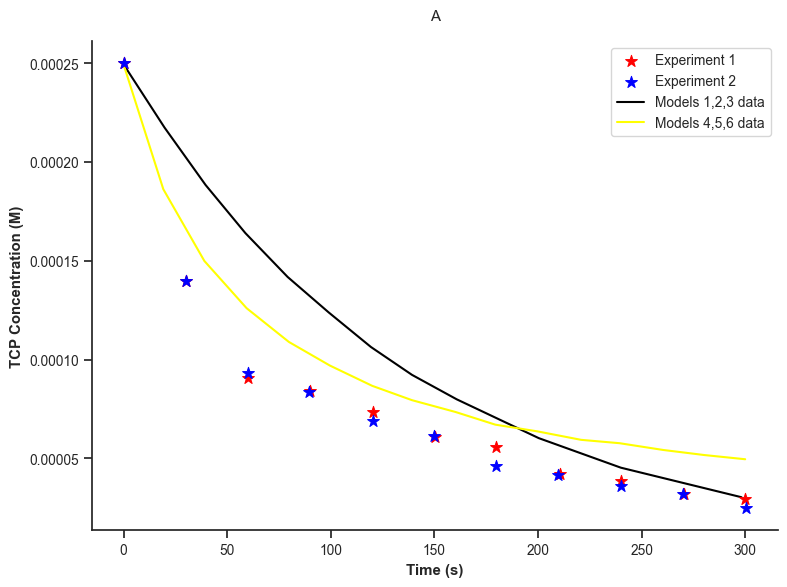

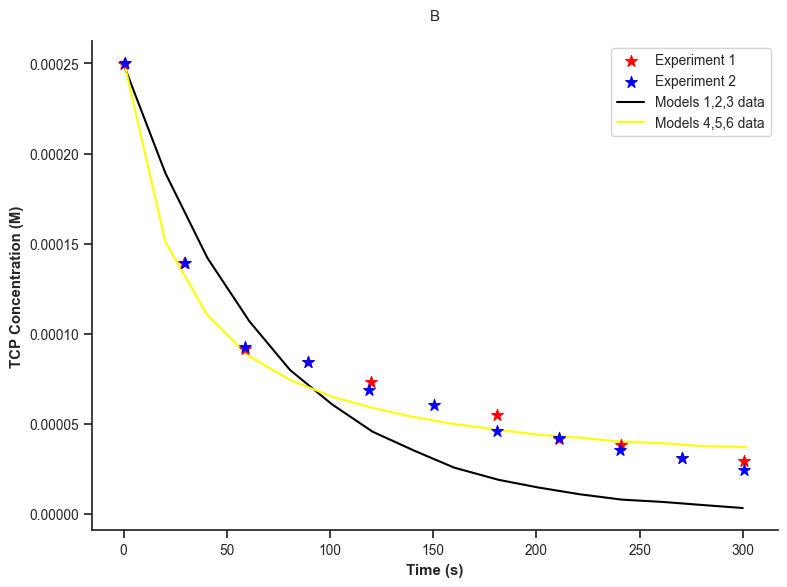

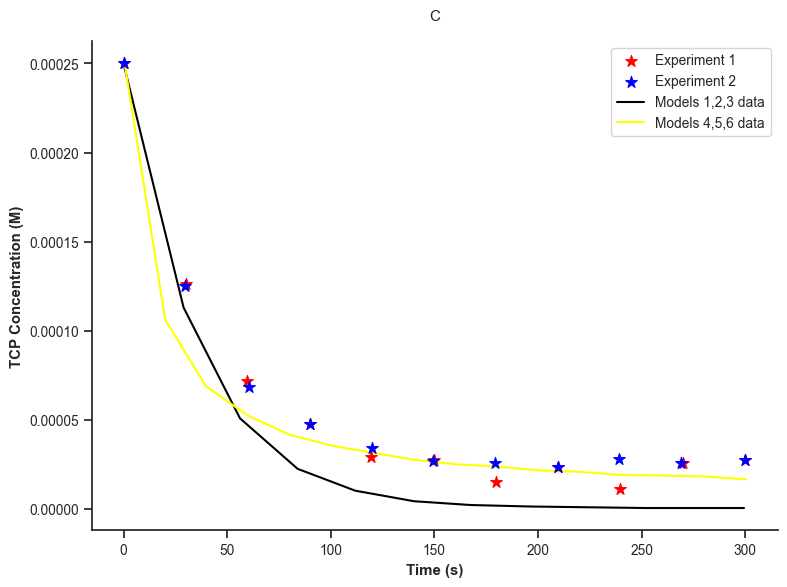

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Carga y preprocesamiento de datos
# ==========================================
labels = ['a', 'b', 'c']
data = {}

for label in labels:
    df1 = pd.read_csv(f"SBP_{label}_exp1.csv")
    df2 = pd.read_csv(f"SBP_{label}_exp2.csv")
    df3 = pd.read_csv(f"SBP_{label}_mod_123.csv")
    df4 = pd.read_csv(f"SBP_{label}_mod_456.csv")
    
    df1 = df1.rename(columns={' y': 'y'})
    df2 = df2.rename(columns={' y': 'y'})
    df3 = df3.rename(columns={' y': 'y'})
    df4 = df4.rename(columns={' y': 'y'})
    
    df1['y'] = df1['y'] * 1e-4  # Convertir a M
    df2['y'] = df2['y'] * 1e-4  # Convertir a M
    df3['y'] = df3['y'] * 1e-4  # Convertir a M
    df4['y'] = df4['y'] * 1e-4  # Convertir a M
    
    data[label] = (df1, df2, df3, df4)

# ==========================================
# Graficar un plot por par de datos
# ==========================================
sns.set_theme(style="ticks", context="notebook", font_scale=0.9)


for label, (df1, df2, df3, df4) in data.items():
    plt.figure(figsize=(8, 6))

    sns.scatterplot(
        x=df1['x'], y=df1['y'],
        color="red", marker="*", s=80,
        edgecolor="red", zorder=3,
        label="Experiment 1"
    )
    sns.scatterplot(
        x=df2['x'], y=df2['y'],
        color="blue", marker="*", s=80,
        edgecolor="blue", zorder=3,
        label="Experiment 2"
    )

    sns.lineplot(
        x=df3['x'], y=df3['y'],
        color="black",
        label="Models 1,2,3 data"
    )
    sns.lineplot(
        x=df4['x'], y=df4['y'],
        color="yellow", 
        label="Models 4,5,6 data"
    )

    plt.xlabel("Time (s)", fontweight='bold')
    plt.ylabel("TCP Concentration (M)", fontweight='bold')
    plt.title(f"{label.upper()}", pad=15)

    sns.despine()
    plt.legend(frameon=True, loc="upper right", shadow=False)
    plt.tight_layout()
    plt.show()

# Definicion de sistemas de ecuaciones 

## Modelo 1

In [2]:
from scipy.integrate import solve_ivp


def modelo_1(t, y, k1, k2, k3):
    # Desempaquetar las variables de estado (Concentraciones en Molar)
    SBP, CpI, CpII, H2O2, TCP, P = y
    
    # Sistema de EDOs según el Modelo 1 (Ecuaciones 12 a 17) 
    d_SBP = -k1 * SBP * H2O2 + k3 * CpII * TCP
    d_CpI = k1 * SBP * H2O2 - k2 * CpI * TCP
    d_CpII = k2 * CpI * TCP - k3 * CpII * TCP
    d_H2O2 = -k1 * SBP * H2O2
    d_TCP = -k2 * CpI * TCP - k3 * CpII * TCP
    d_P = k2 * CpI * TCP + k3 * CpII * TCP
    
    return [d_SBP, d_CpI, d_CpII, d_H2O2, d_TCP, d_P]

# ==========================================
# Parámetros del Modelo 1 (Tabla 2) 
# ==========================================
#parámetros modelo 4
k1_1 = 2.0e7
k2_1 = 6.4e6
k3_1 = 2.5e5

## Modelo 2

In [3]:
def modelo_2(t, y, k1, k2, k3, kapp, ka, kb, kc):
    # Variables de estado
    SBP, CpI, CpII, H2O2, TCP, CpIII, P = y
    
    # Sistema de EDOs
    d_SBP = -k1 * SBP * H2O2 + k3 * CpII * TCP + ka * CpIII + kc * CpI * H2O2
    d_CpI = k1 * SBP * H2O2 - k2 * CpI * TCP + kb * CpIII * TCP - kc * CpI * H2O2
    d_CpII = k2 * CpI * TCP - k3 * CpII * TCP - kapp * CpII * H2O2
    d_CpIII = kapp * CpII * H2O2 - ka * CpIII - kb * CpIII * TCP
    
    d_H2O2 = -k1 * SBP * H2O2 - kapp * CpII * H2O2 - kc * CpI * H2O2
    d_TCP = -k2 * CpI * TCP - k3 * CpII * TCP - kb * CpIII * TCP
    d_P = k2 * CpI * TCP + k3 * CpII * TCP + kb * CpIII * TCP
    
    return [d_SBP, d_CpI, d_CpII, d_H2O2, d_TCP, d_CpIII, d_P]

# ==========================================
# Parámetros del Modelo 2 (Tabla 2) 
# ==========================================
#parámetros modelo 4
k1_2 = 2.0e7 
k2_2 = 6.4e6
k3_2 = 2.5e5
#parámetros modelo 2
kapp_2 = 7.92e-1 
ka_2 = 4.28e-2 
kb_2 = 4.23e-1 
kc_2 = 1.96e2

## Modelo 3

In [4]:
def modelo_3(t, y, k1, k2, k3, kapp, ka, kb, k4, k_minus4, k5):
    # Variables de estado
    SBP, CpI, CpII, H2O2, TCP, CpIII, CpI_H2O2, P = y
    
    # Sistema de EDOs
    d_SBP = -k1 * SBP * H2O2 + k3 * CpII * TCP + ka * CpIII + k5 * CpI_H2O2
    d_CpI = k1 * SBP * H2O2 - k2 * CpI * TCP + kb * CpIII * TCP - k4 * CpI * H2O2 + k_minus4 * CpI_H2O2
    d_CpII = k2 * CpI * TCP - k3 * CpII * TCP - kapp * CpII * H2O2
    d_CpIII = kapp * CpII * H2O2 - ka * CpIII - kb * CpIII * TCP
    d_CpI_H2O2 = k4 * CpI * H2O2 - k_minus4 * CpI_H2O2 - k5 * CpI_H2O2
    
    d_H2O2 = -k1 * SBP * H2O2 - kapp * CpII * H2O2 - k4 * CpI * H2O2 + k_minus4 * CpI_H2O2
    d_TCP = -k2 * CpI * TCP - k3 * CpII * TCP - kb * CpIII * TCP
    d_P = k2 * CpI * TCP + k3 * CpII * TCP + kb * CpIII * TCP
    
    return [d_SBP, d_CpI, d_CpII, d_H2O2, d_TCP, d_CpIII, d_CpI_H2O2, d_P]

# ==========================================
#  Parámetros del Modelo 3 (Tabla 2) 
# ==========================================
#parámetros modelo 4
k1_3 = 2.0e7 
k2_3 = 6.4e6
k3_3 = 2.5e5

#parámetros modelo 3
kapp_3 = 8.99e-2 
ka_3 = 6.48e-2 
kb_3 = 3.74e-1 
k4_3 = 3.41e1  
k_minus4_3 = 7.26e-7 
k5_3 = 1.41e0

## Modelo 4

In [5]:
# ==========================================
# 1. Definición del Sistema de Ecuaciones (Modelo 4)
# ==========================================

def modelo_4(t, y, k1, k2, k3, Ks):
    SBP, CpI, CpII, H2O2, TCP, P, SBP_inact = y
    
    # Velocidad de consumo de TCP (reacciones 2 y 3)
    rate_TCP_consumo = k2 * CpI * TCP + k3 * CpII * TCP
    

    # Tasa de inactivación de la enzima (derivada de la Eq. 11)
    d_SBP_inact = rate_TCP_consumo / Ks
    
    # Sistema de EDOs
    d_SBP = -k1 * SBP * H2O2 + k3 * CpII * TCP - d_SBP_inact
    d_CpI = k1 * SBP * H2O2 - k2 * CpI * TCP
    d_CpII = k2 * CpI * TCP - k3 * CpII * TCP
    d_H2O2 = -k1 * SBP * H2O2
    d_TCP = -rate_TCP_consumo
    d_P = rate_TCP_consumo
    
    return [d_SBP, d_CpI, d_CpII, d_H2O2, d_TCP, d_P, d_SBP_inact]
# ==========================================
# Parámetros del Modelo 4 (Tabla 2) 
# ==========================================
#parámetros modelo 1
k1_4 = 2.0e7
k2_4 = 3.4e6
k3_4 = 8.8e5

## Modelo 5

In [6]:
def modelo_5(t, y, k1, k2, k3, kapp, ka, kb, kc, Ks):
    # Variables de estado
    SBP, CpI, CpII, H2O2, TCP, CpIII, P, SBP_inact = y
    
    # Velocidad de consumo de TCP (reacciones 2, 3 y 6 del paper)
    rate_TCP_consumo = k2 * CpI * TCP + k3 * CpII * TCP + kb * CpIII * TCP
    
    # Tasa de inactivación
    d_SBP_inact = rate_TCP_consumo / Ks
    
    # Sistema de EDOs
    d_SBP = -k1 * SBP * H2O2 + k3 * CpII * TCP + ka * CpIII + kc * CpI * H2O2 - d_SBP_inact
    d_CpI = k1 * SBP * H2O2 - k2 * CpI * TCP + kb * CpIII * TCP - kc * CpI * H2O2
    d_CpII = k2 * CpI * TCP - k3 * CpII * TCP - kapp * CpII * H2O2
    d_CpIII = kapp * CpII * H2O2 - ka * CpIII - kb * CpIII * TCP
    
    d_H2O2 = -k1 * SBP * H2O2 - kapp * CpII * H2O2 - kc * CpI * H2O2
    d_TCP = -rate_TCP_consumo
    d_P = rate_TCP_consumo
    
    return [d_SBP, d_CpI, d_CpII, d_H2O2, d_TCP, d_CpIII, d_P, d_SBP_inact]


# ==========================================
# Parámetros del Modelo 5 (Tabla 2) 
# ==========================================
#parámetros modelo 2
k1_5 = 2.0e7 
k2_5 = 2.52e6 
k3_5 = 9.72e5 
kapp_5 = 7.92e-1 
ka_5 = 4.28e-2 
kb_5 = 4.23e-1 
kc_5 = 1.96e2

## Modelo 6

In [7]:
def modelo_6(t, y, k1, k2, k3, kapp, ka, kb, k4, k_minus4, k5, Ks):
    # Variables de estado
    SBP, CpI, CpII, H2O2, TCP, CpIII, CpI_H2O2, P, SBP_inact = y
    
    # Velocidad de consumo de TCP
    rate_TCP_consumo = k2 * CpI * TCP + k3 * CpII * TCP + kb * CpIII * TCP
    
    # Tasa de inactivación
    d_SBP_inact = rate_TCP_consumo / Ks
    
    # Sistema de EDOs
    d_SBP = -k1 * SBP * H2O2 + k3 * CpII * TCP + ka * CpIII + k5 * CpI_H2O2 - d_SBP_inact
    d_CpI = k1 * SBP * H2O2 - k2 * CpI * TCP + kb * CpIII * TCP - k4 * CpI * H2O2 + k_minus4 * CpI_H2O2
    d_CpII = k2 * CpI * TCP - k3 * CpII * TCP - kapp * CpII * H2O2
    d_CpIII = kapp * CpII * H2O2 - ka * CpIII - kb * CpIII * TCP
    d_CpI_H2O2 = k4 * CpI * H2O2 - k_minus4 * CpI_H2O2 - k5 * CpI_H2O2
    
    d_H2O2 = -k1 * SBP * H2O2 - kapp * CpII * H2O2 - k4 * CpI * H2O2 + k_minus4 * CpI_H2O2
    d_TCP = -rate_TCP_consumo
    d_P = rate_TCP_consumo
    
    return [d_SBP, d_CpI, d_CpII, d_H2O2, d_TCP, d_CpIII, d_CpI_H2O2, d_P, d_SBP_inact]

# ==========================================
# Parámetros del Modelo 6 (Tabla 2) 
# ==========================================
#parámetros modelo 3
k1_6 = 2.0e7 
k2_6 = 3.36e6 
k3_6 = 8.85e5 
kapp_6 = 8.99e-2 
ka_6 = 6.48e-2 
kb_6 = 3.74e-1 
k4_6 = 3.41e1  
k_minus4_6 = 7.26e-7 
k5_6 = 1.41e0

# Condiciones iniciales y solución

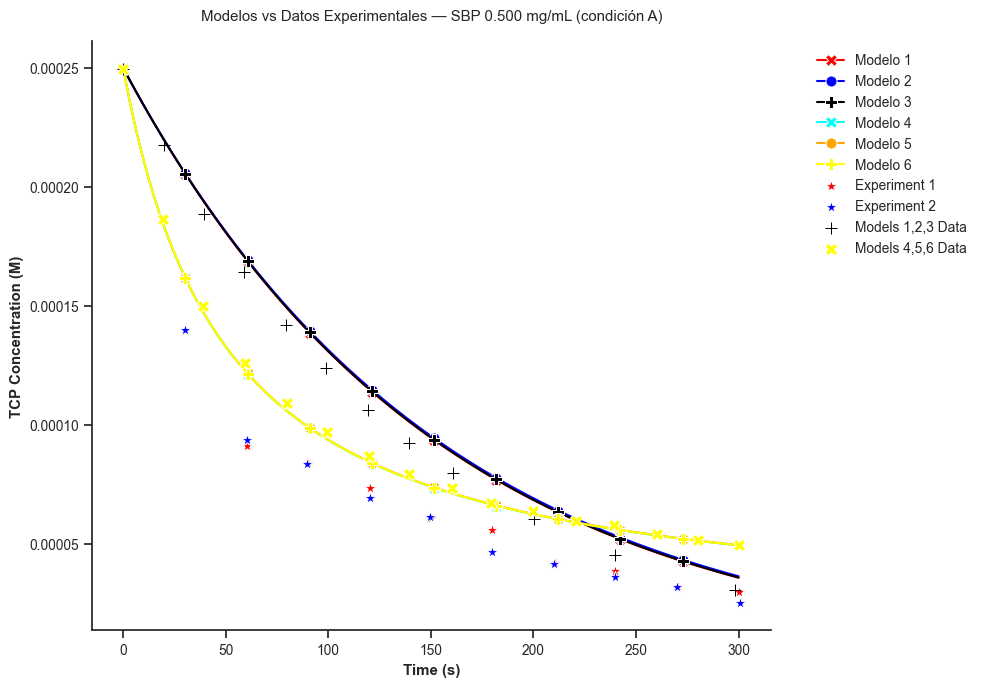

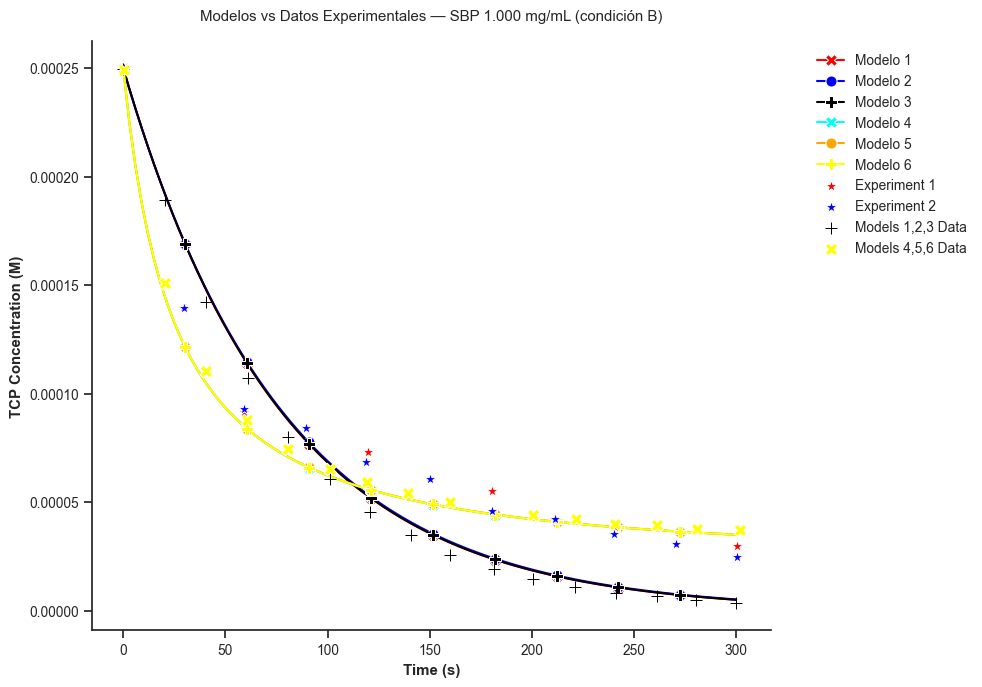

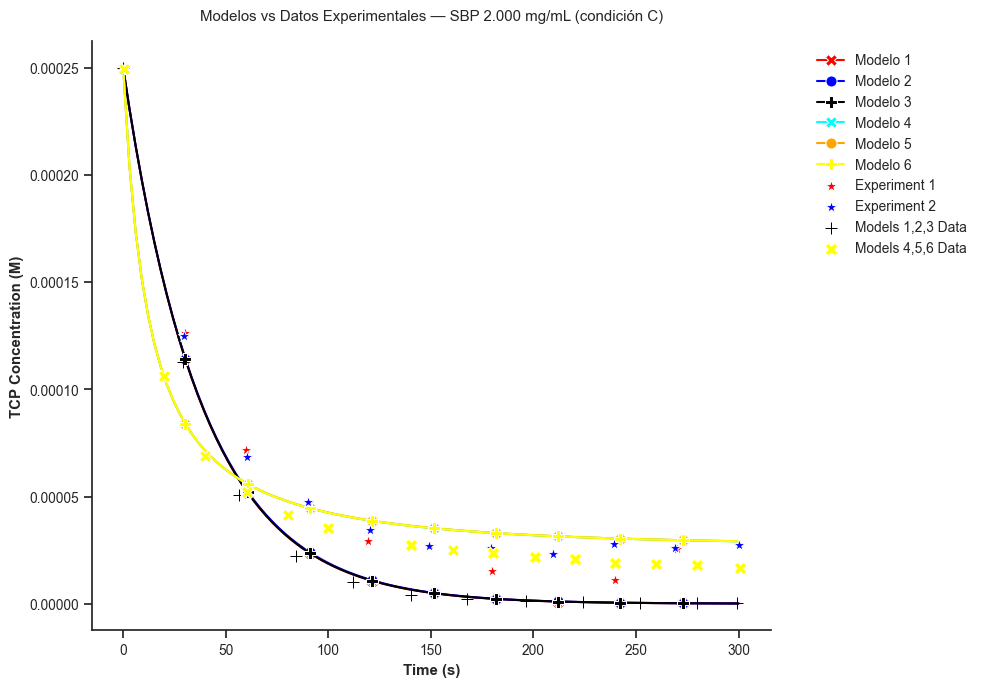

In [8]:
# ==========================================
# Constantes que no cambian entre experimentos
# ==========================================
TCP_0      = 0.25e-3
H2O2_0     = 0.6e-3
P_0        = CpI_0 = CpII_0 = CpIII_0 = CpI_H2O2_0 = SBP_inact_0 = 0.0
MW_SBP     = 37000  #g/mol

# Peso molecular SBP
MW_SBP = 37000  #g/mol

# Concentración inicial de enzima en mg/mL
SBPa_mg_mL = 0.0005
SBPb_mg_mL = 0.001
SBPc_mg_mL = 0.002

t_span = (0, 300)
t_eval = np.linspace(*t_span, 100)

# Mapeo de SBP
sbp_vars = {
    'a': SBPa_mg_mL, 
    'b': SBPb_mg_mL, 
    'c': SBPc_mg_mL
}

condiciones = {}
# Armamos un nuevo diccionario iterando sobre las etiquetas
for label in labels:
    condiciones[label] = {
        'SBP_mg_mL': sbp_vars[label],
        'df_exp1': data[label][0],      # Data experimental 1
        'df_exp2': data[label][1],      # Data experimental 2
        'df_mod_123': data[label][2],   # Curva extraída Modelos 1, 2, 3
        'df_mod_456': data[label][3]    # Curva extraída Modelos 4, 5, 6 
    }

# ==========================================
# Loop principal
# ==========================================
# Guardamos todos los resultados de experimentos
resultados_por_condicion = {}

for label, cond in condiciones.items():

# Condición inicial de SBP y Ks
    SBP_0 = condiciones[label]['SBP_mg_mL'] / MW_SBP
    TCP_f = (condiciones[label]['df_exp1']['y'].iloc[-1] + condiciones[label]['df_exp2']['y'].iloc[-1]) / 2
    Ks_local    = (TCP_0 - TCP_f) / SBP_0

# Condiciones iniciales por modelo
    y0s = {
        1: [SBP_0, CpI_0, CpII_0, H2O2_0, TCP_0, P_0],
        2: [SBP_0, CpI_0, CpII_0, H2O2_0, TCP_0, CpIII_0, P_0],
        3: [SBP_0, CpI_0, CpII_0, H2O2_0, TCP_0, CpIII_0, CpI_H2O2_0, P_0],
        4: [SBP_0, CpI_0, CpII_0, H2O2_0, TCP_0, P_0, SBP_inact_0],
        5: [SBP_0, CpI_0, CpII_0, H2O2_0, TCP_0, CpIII_0, P_0, SBP_inact_0],
        6: [SBP_0, CpI_0, CpII_0, H2O2_0, TCP_0, CpIII_0, CpI_H2O2_0, P_0, SBP_inact_0],
    }
    
    # Solver BDF para los 6 modelos
    soluciones_raw = {
        'Modelo 1': solve_ivp(modelo_1, t_span, y0s[1], method='BDF', t_eval=t_eval,
                              args=(k1_1, k2_1, k3_1), rtol=1e-8, atol=1e-10),
        'Modelo 2': solve_ivp(modelo_2, t_span, y0s[2], method='BDF', t_eval=t_eval,
                              args=(k1_2, k2_2, k3_2, kapp_2, ka_2, kb_2, kc_2), rtol=1e-8, atol=1e-10),
        'Modelo 3': solve_ivp(modelo_3, t_span, y0s[3], method='BDF', t_eval=t_eval,
                              args=(k1_3, k2_3, k3_3, kapp_3, ka_3, kb_3, k4_3, k_minus4_3, k5_3), rtol=1e-8, atol=1e-10),
        'Modelo 4': solve_ivp(modelo_4, t_span, y0s[4], method='BDF', t_eval=t_eval,
                              args=(k1_4, k2_4, k3_4, Ks_local), rtol=1e-8, atol=1e-10),
        'Modelo 5': solve_ivp(modelo_5, t_span, y0s[5], method='BDF', t_eval=t_eval,
                              args=(k1_5, k2_5, k3_5, kapp_5, ka_5, kb_5, kc_5, Ks_local), rtol=1e-8, atol=1e-10),
        'Modelo 6': solve_ivp(modelo_6, t_span, y0s[6], method='BDF', t_eval=t_eval,
                              args=(k1_6, k2_6, k3_6, kapp_6, ka_6, kb_6, k4_6, k_minus4_6, k5_6, Ks_local), rtol=1e-8, atol=1e-10),
    }

    # Armar DataFrame long-form para seaborn
    df_sim = pd.concat([
        pd.DataFrame({'Time': sol.t, 'TCP_mM': sol.y[4], 'Modelo': nombre})
        for nombre, sol in soluciones_raw.items()
    ], ignore_index=True)

    # Guardamos para acceder después
    resultados_por_condicion[label] = {
        'soluciones': soluciones_raw,
        'df_sim': df_sim,
        'Ks': Ks_local,
        'SBP_0': SBP_0,
    }
    
    # ==========================================
    # 4. Visualización
    # ==========================================
    colores_custom   = {'Modelo 1':'red',  'Modelo 2':'blue', 'Modelo 3':'black',
                        'Modelo 4':'cyan', 'Modelo 5':'orange','Modelo 6':'yellow'}
    marcadores_custom = {'Modelo 1':'X', 'Modelo 2':'o', 'Modelo 3':'P',
                         'Modelo 4':'X', 'Modelo 5':'o', 'Modelo 6':'P'}

    sns.set_theme(style="ticks", context="notebook", font_scale=0.9)
    plt.figure(figsize=(10, 7))

    sns.lineplot(data=df_sim, x='Time', y='TCP_mM', hue='Modelo',
                 palette=colores_custom, style='Modelo', markers=marcadores_custom,
                 dashes=False, linewidth=1.5, markevery=10, markersize=8)

    sns.scatterplot(x=condiciones[label]['df_exp1']['x'], y=condiciones[label]['df_exp1']['y'],
                    color="red",  marker="*", s=80,  zorder=3, label="Experiment 1")
    sns.scatterplot(x=condiciones[label]['df_exp2']['x'], y=condiciones[label]['df_exp2']['y'],
                    color="blue", marker="*", s=80, zorder=3, label="Experiment 2")
    sns.scatterplot(x=condiciones[label]['df_mod_123']['x'], y=condiciones[label]['df_mod_123']['y'],
                    color="black",  marker="+", s=80,  zorder=3, label="Models 1,2,3 Data")
    sns.scatterplot(x=condiciones[label]['df_mod_456']['x'], y=condiciones[label]['df_mod_456']['y'],
                    color="yellow", marker="X", s=80, zorder=3, label="Models 4,5,6 Data")

    plt.xlabel("Time (s)", fontweight='bold')
    plt.ylabel("TCP Concentration (M)", fontweight='bold')
    plt.title(f"Modelos vs Datos Experimentales — SBP {cond['SBP_mg_mL']*1000:.3f} mg/mL (condición {label.upper()})", pad=15)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
    sns.despine()
    plt.tight_layout()
    plt.show()

    

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=ee6d1ece-4991-456b-8b0a-72d4d9cb5c62' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>